I. Features Engineering

In [115]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [116]:
df=pd.read_csv('VN_housing_dataset.csv')

In [117]:
df.head(20)

,Unnamed: 0,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
0,0,2020-08-05,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...",Quận Cầu Giấy,Phường Nghĩa Đô,"Nhà ngõ, hẻm",Đã có sổ,4,5 phòng,46 m²,NaN,NaN,"86,96 triệu/m²"
1,1,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,37 m²,NaN,NaN,"116,22 triệu/m²"
2,2,2020-08-05,"phố minh khai, Phường Minh Khai, Quận Hai Bà T...",Quận Hai Bà Trưng,Phường Minh Khai,"Nhà ngõ, hẻm",Đã có sổ,4,4 phòng,40 m²,10 m,4 m,65 triệu/m²
3,3,2020-08-05,"Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ,...",Quận Tây Hồ,Phường Thụy Khuê,"Nhà ngõ, hẻm",Đã có sổ,NaN,6 phòng,51 m²,12.75 m,4 m,100 triệu/m²
4,4,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,36 m²,9 m,4 m,"86,11 triệu/m²"
5,5,2020-08-05,"Đường Yên Hòa, Phường Yên Hoà, Quận Cầu Giấy, ...",Quận Cầu Giấy,Phường Yên Hoà,"Nhà ngõ, hẻm",Đã có sổ,NaN,nhiều hơn 10 phòng,46 m²,12.1 m,3.8 m,"104,35 triệu/m²"
6,6,2020-08-05,"Đường Tây Sơn, Phường Trung Liệt, Quận Đống Đa...",Quận Đống Đa,Phường Trung Liệt,"Nhà ngõ, hẻm",NaN,NaN,3 phòng,52 m²,NaN,4.5 m,"112,5 triệu/m²"
7,7,2020-08-05,"Đường Lò Đúc, Phường Đống Mác, Quận Hai Bà Trư...",Quận Hai Bà Trưng,Phường Đống Mác,"Nhà mặt phố, mặt tiền",Đã có sổ,6,5 phòng,32 m²,NaN,6.8 m,"184,38 triệu/m²"
8,8,2020-08-05,"Đường Xuân La, Phường Xuân La, Quận Tây Hồ, Hà...",Quận Tây Hồ,Phường Xuân La,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,75 m²,12 m,6.5 m,120 triệu/m²
9,9,2020-08-05,"Đường 19/5, Phường Văn Quán, Quận Hà Đông, Hà Nội",Quận Hà Đông,Phường Văn Quán,"Nhà ngõ, hẻm",Đã có sổ,4,3 phòng,41 m²,NaN,3.5 m,"64,63 triệu/m²"


In [118]:
for col in df.columns:
    ordinal=df[col].nunique()
    print(f"{col}: {ordinal}.")

Unnamed: 0: 82496.
Ngày: 174.
Địa chỉ: 13957.
Quận: 29.
Huyện: 309.
Loại hình nhà ở: 4.
Giấy tờ pháp lý: 3.
Số tầng: 29.
Số phòng ngủ: 11.
Diện tích: 504.
Dài: 487.
Rộng: 410.
Giá/m2: 8345.


In [119]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.drop(columns=['Địa chỉ', 'Số tầng', 'Dài', 'Rộng'], errors='ignore')

In [120]:
df['ngày_temp'] = pd.to_datetime(df['Ngày'])
df['ngày'] = df['ngày_temp'].dt.day
df['tháng'] = df['ngày_temp'].dt.month
df['năm'] = df['ngày_temp'].dt.year
df['năm'] = df['năm'].astype('str').str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
df = df.drop(columns=['ngày_temp'])
df = df.drop(columns=['Ngày'], errors='ignore')

In [121]:
df['Giá/m2'] = df['Giá/m2'].astype(str).str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
df['Giá/m2'] = pd.to_numeric(df['Giá/m2'], errors='coerce') * 1_000_000
df['Giá/m2'] = df['Giá/m2'].fillna(0).astype(int)
pd.options.display.float_format = '{:,.0f}'.format

In [122]:

df['Số phòng ngủ'] = df['Số phòng ngủ'].astype(str).str.replace('nhiều hơn 10 phòng', '11')
df['Số phòng ngủ'] = df['Số phòng ngủ'].str.replace('phòng', '').str.strip()
df['Số phòng ngủ'] = pd.to_numeric(df['Số phòng ngủ'], errors='coerce').astype('Int64')

In [123]:
df['Diện tích'] = df['Diện tích'].astype(str).str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
df['Diện tích'] = pd.to_numeric(df['Diện tích'], errors='coerce')
df['Diện tích'] = df['Diện tích'].fillna(0).astype(int)

In [124]:
df['năm'] = pd.to_numeric(df['năm'], errors='coerce').astype('Int64')
df['ngày'] = pd.to_numeric(df['ngày'], errors='coerce').astype('Int64')
df['tháng'] = pd.to_numeric(df['tháng'], errors='coerce').astype('Int64')

In [125]:
categorical_imputer_a=df['Quận'].mode()[0]
categorical_imputer_b=df['Huyện'].mode()[0]
categorical_imputer_c=df['Loại hình nhà ở'].mode()[0]
categorical_imputer_d=df['Giấy tờ pháp lý'].mode()[0]
df['Quận'] = df['Quận'].fillna(categorical_imputer_a)
df['Huyện'] = df['Huyện'].fillna(categorical_imputer_b)
df['Loại hình nhà ở'] = df['Loại hình nhà ở'].fillna(categorical_imputer_c)
df['Giấy tờ pháp lý'] = df['Giấy tờ pháp lý'].fillna(categorical_imputer_d)

In [126]:
numerical_imputer_a=df['Số phòng ngủ'].median()
numerical_imputer_b=df['Diện tích'].median()
numerical_imputer_c=df['ngày'].median()
numerical_imputer_d=df['tháng'].median()
numerical_imputer_e=df['năm'].median()
df['Số phòng ngủ'] = df['Số phòng ngủ'].fillna(numerical_imputer_a)
df['Diện tích'] = df['Diện tích'].fillna(numerical_imputer_b)
df['ngày'] = df['ngày'].fillna(numerical_imputer_c)
df['tháng'] = df['tháng'].fillna(numerical_imputer_d)
df['năm'] = df['năm'].fillna(numerical_imputer_e)

In [127]:
df['Quận']=LabelEncoder().fit_transform(df['Quận'])
df['Huyện']=LabelEncoder().fit_transform(df['Huyện'])
df['Loại hình nhà ở']=LabelEncoder().fit_transform(df['Loại hình nhà ở'])
df['Giấy tờ pháp lý']=LabelEncoder().fit_transform(df['Giấy tờ pháp lý'])

In [128]:
df_cleaned=df[(df['Diện tích'] > 20) & (df['Diện tích'] < 300)]
df_cleaned=df_cleaned[(df_cleaned['Giá/m2'] > 20_000_000) & (df_cleaned['Giá/m2'] < 400_000_000)]

In [129]:
# Tạo các đặc trưng mới (Feature Engineering)
print("🔧 FEATURE ENGINEERING")
print("="*60)

# 1. Giá trị cơ bản (Basic Features)
df['price_per_room'] = df['Giá/m2'] * df['Diện tích'] / (df['Số phòng ngủ'] + 1)  # +1 để tránh chia cho 0
df['area_per_room'] = df['Diện tích'] / (df['Số phòng ngủ'] + 1)
df['rooms_per_100m2'] = (df['Số phòng ngủ'] / df['Diện tích']) * 100

# 2. Phân loại mức giá
price_33 = df['Giá/m2'].quantile(0.33)
price_67 = df['Giá/m2'].quantile(0.67)
df['price_level'] = pd.cut(df['Giá/m2'], bins=[0, price_33, price_67, float('inf')], labels=['Budget', 'Mid-range', 'Premium'], ordered=True)

# 3. Phân loại kích thước diện tích
area_33 = df['Diện tích'].quantile(0.33)
area_67 = df['Diện tích'].quantile(0.67)
df['area_category'] = pd.cut(df['Diện tích'], bins=[0, area_33, area_67, float('inf')], labels=['Small', 'Medium', 'Large'], ordered=True)

# 4. Thời gian trong năm
df['is_peak_season'] = df['tháng'].isin([4, 5, 9, 10]).astype(int)  # Tháng cao điểm bất động sản
df['is_winter'] = df['tháng'].isin([11, 12, 1, 2]).astype(int)  # Mùa đông
df['is_summer'] = df['tháng'].isin([6, 7, 8]).astype(int)  # Mùa hè
df['is_quarter_end'] = df['tháng'].isin([3, 6, 9, 12]).astype(int)  # Cuối quý

# 5. Thời gian tin đăng (Listing age)
current_year = df['năm'].max()
df['listing_age'] = current_year - df['năm']

# 6. Mối quan hệ giữa số phòng và diện tích
df['room_area_ratio'] = df['Số phòng ngủ'] / (df['Diện tích'] + 1)

# 7. Tổng điểm đánh giá bất động sản (Property Score)
# Tính điểm dựa trên các yếu tố: diện tích, số phòng, đặc quyền pháp lý
df['property_score'] = (
    (df['Diện tích'] / df['Diện tích'].max() * 30) +  # 30 điểm cho diện tích
    (df['Số phòng ngủ'] / df['Số phòng ngủ'].max() * 20) +  # 20 điểm cho số phòng
    (df['Giấy tờ pháp lý'] / df['Giấy tờ pháp lý'].max() * 20) +  # 20 điểm cho giấy tờ
    ((df['Quận'] + 1) / (df['Quận'].max() + 1) * 30)  # 30 điểm cho vị trí (quận)
)

# 8. Chỉ số location (Quận và Huyện kết hợp)
df['location_score'] = df['Quận'] * 10 + df['Huyện']

# Encode các biến categorical mới
df['price_level'] = LabelEncoder().fit_transform(df['price_level'].astype(str))
df['area_category'] = LabelEncoder().fit_transform(df['area_category'].astype(str))

print(f"\n✅ Tạo thành công {8} nhóm đặc trưng mới:")
print("  1️⃣  price_per_room: Giá cho mỗi phòng ngủ")
print("  2️⃣  area_per_room: Diện tích trung bình mỗi phòng")
print("  3️⃣  rooms_per_100m2: Số phòng trên 100m²")
print("  4️⃣  price_level: Phân loại mức giá (Budget/Mid-range/Premium)")
print("  5️⃣  area_category: Phân loại kích thước (Small/Medium/Large)")
print("  6️⃣  Mùa: is_peak_season, is_winter, is_summer, is_quarter_end")
print("  7️⃣  listing_age: Tuổi tin đăng (năm)")
print("  8️⃣  property_score: Chỉ số đánh giá bất động sản")
print("  9️⃣  room_area_ratio: Tỷ lệ phòng/diện tích")
print("  🔟  location_score: Chỉ số vị trí địa lý")

# Hiển thị dữ liệu mới
print("\n📋 Các đặc trưng mới trong dữ liệu:")
print(df[['price_per_room', 'area_per_room', 'rooms_per_100m2', 'price_level', 
          'area_category', 'property_score', 'listing_age']].head(10))

print("\n📊 Thống kê các đặc trưng mới:")
print(df[['price_per_room', 'area_per_room', 'rooms_per_100m2', 'property_score', 'listing_age']].describe())


🔧 FEATURE ENGINEERING

✅ Tạo thành công 8 nhóm đặc trưng mới:
  1️⃣  price_per_room: Giá cho mỗi phòng ngủ
  2️⃣  area_per_room: Diện tích trung bình mỗi phòng
  3️⃣  rooms_per_100m2: Số phòng trên 100m²
  4️⃣  price_level: Phân loại mức giá (Budget/Mid-range/Premium)
  5️⃣  area_category: Phân loại kích thước (Small/Medium/Large)
  6️⃣  Mùa: is_peak_season, is_winter, is_summer, is_quarter_end
  7️⃣  listing_age: Tuổi tin đăng (năm)
  8️⃣  property_score: Chỉ số đánh giá bất động sản
  9️⃣  room_area_ratio: Tỷ lệ phòng/diện tích
  🔟  location_score: Chỉ số vị trí địa lý

📋 Các đặc trưng mới trong dữ liệu:
   price_per_room  area_per_room  rooms_per_100m2  price_level  area_category  \
0     666,693,333              8               11            1              1   
1   1,075,035,000              9                8            2              1   
2     520,000,000              8               10            0              1   
3     728,571,429              7               12            1

In [130]:
df['price_per_room'] = df['price_per_room'].astype(str).str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
df['price_per_room'] = pd.to_numeric(df['price_per_room'], errors='coerce')
df['price_per_room'] = df['price_per_room'].fillna(0).astype(int)
pd.options.display.float_format = '{:,.0f}'.format

In [131]:
print(df.dtypes)

Quận                 int64
Huyện                int64
Loại hình nhà ở      int64
Giấy tờ pháp lý      int64
Số phòng ngủ         Int64
Diện tích            int64
Giá/m2               int64
ngày                 Int64
tháng                Int64
năm                  Int64
price_per_room       int64
area_per_room      Float64
rooms_per_100m2    Float64
price_level          int64
area_category        int64
is_peak_season       int64
is_winter            int64
is_summer            int64
is_quarter_end       int64
listing_age          Int64
room_area_ratio    Float64
property_score     Float64
location_score       int64
dtype: object


In [132]:
df['area_per_room'] = pd.to_numeric(df['area_per_room'], errors='coerce').astype('Int64')
df['rooms_per_100m2'] = pd.to_numeric(df['rooms_per_100m2'], errors='coerce').astype('Int64')
df['room_area_ratio'] = pd.to_numeric(df['room_area_ratio'], errors='coerce').astype('Int64')
df['property_score'] = pd.to_numeric(df['property_score'], errors='coerce').astype('Int64')

In [138]:
# Tạo lại df_cleaned với tất cả các đặc trưng đã được tạo
print("🔄 Tạo lại df_cleaned với tất cả đặc trưng...")
df_cleaned = df[(df['Diện tích'] > 20) & (df['Diện tích'] < 300)].copy()
df_cleaned = df_cleaned[(df_cleaned['Giá/m2'] > 20_000_000) & (df_cleaned['Giá/m2'] < 400_000_000)].copy()
print(f"✅ df_cleaned có {df_cleaned.shape[0]} dòng và {df_cleaned.shape[1]} cột")
print(f"✅ Các cột trong df_cleaned: {list(df_cleaned.columns)}")


🔄 Tạo lại df_cleaned với tất cả đặc trưng...
✅ df_cleaned có 79343 dòng và 23 cột
✅ Các cột trong df_cleaned: ['Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Số phòng ngủ', 'Diện tích', 'Giá/m2', 'ngày', 'tháng', 'năm', 'price_per_room', 'area_per_room', 'rooms_per_100m2', 'price_level', 'area_category', 'is_peak_season', 'is_winter', 'is_summer', 'is_quarter_end', 'listing_age', 'room_area_ratio', 'property_score', 'location_score']


II. EDA

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [66]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

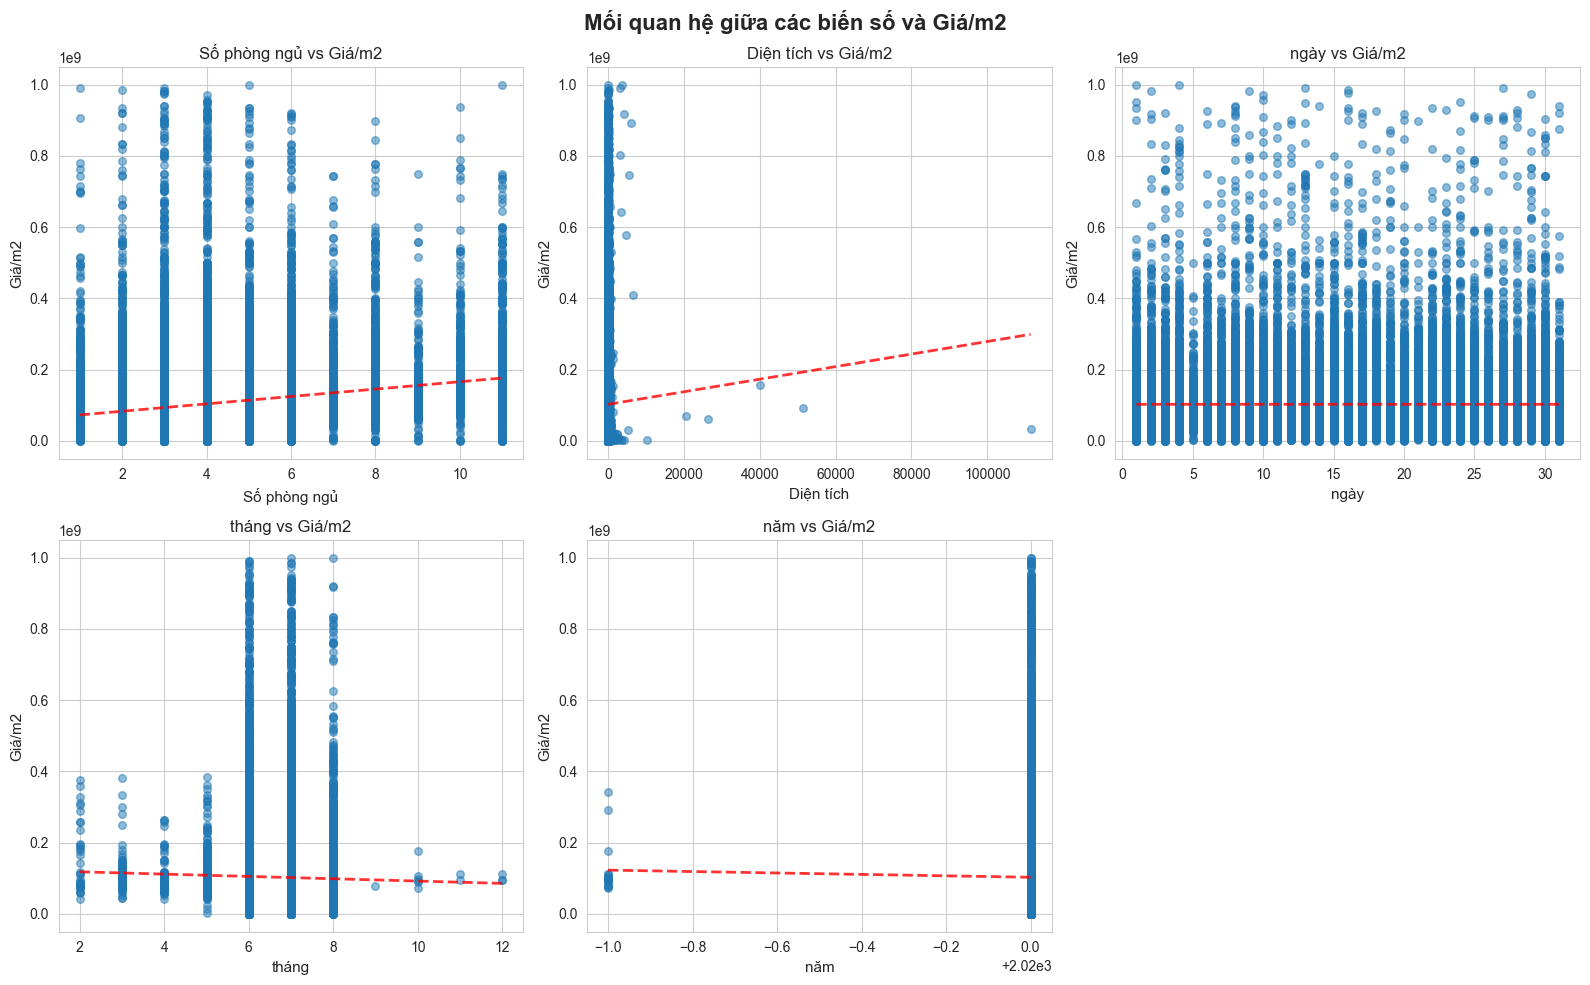

In [67]:
# 1. Biến số và mối quan hệ với Giá/m2
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Mối quan hệ giữa các biến số và Giá/m2', fontsize=16, fontweight='bold')

numerical_cols = ['Số phòng ngủ', 'Diện tích', 'ngày', 'tháng', 'năm']

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]
    
    ax.scatter(df[col], df['Giá/m2'], alpha=0.5, s=30)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Giá/m2', fontsize=11)
    ax.set_title(f'{col} vs Giá/m2', fontsize=12)
    
    # Thêm trend line
    z = np.polyfit(df[col].dropna(), df['Giá/m2'].dropna(), 1)
    p = np.poly1d(z)
    ax.plot(df[col].sort_values(), p(df[col].sort_values()), "r--", alpha=0.8, linewidth=2)

# Xóa subplot trống
axes[1, 2].remove()
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_22228\3492184184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Giá/m2', data=df, ax=ax, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_22228\3492184184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Giá/m2', data=df, ax=ax, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_22228\3492184184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Giá/m2', data=df, ax=ax, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_22228\3492184184.py:

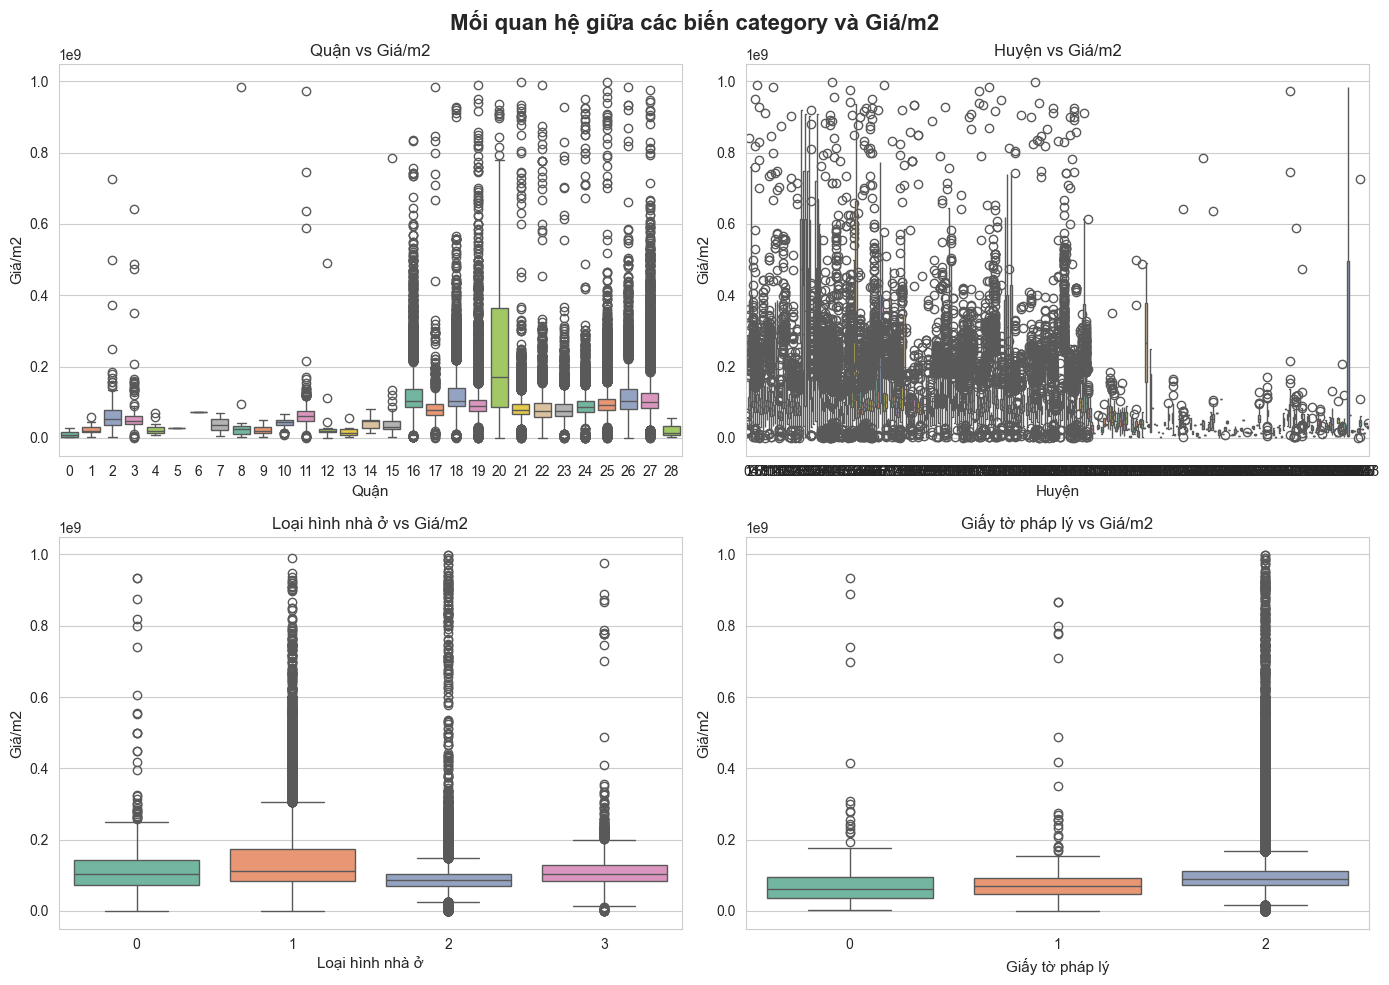

In [68]:
# 2. Biến category và mối quan hệ với Giá/m2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mối quan hệ giữa các biến category và Giá/m2', fontsize=16, fontweight='bold')

categorical_cols = ['Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý']

for idx, col in enumerate(categorical_cols):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row, col_idx]
    
    sns.boxplot(x=col, y='Giá/m2', data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Giá/m2', fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Giá/m2', fontsize=11)

plt.tight_layout()
plt.show()

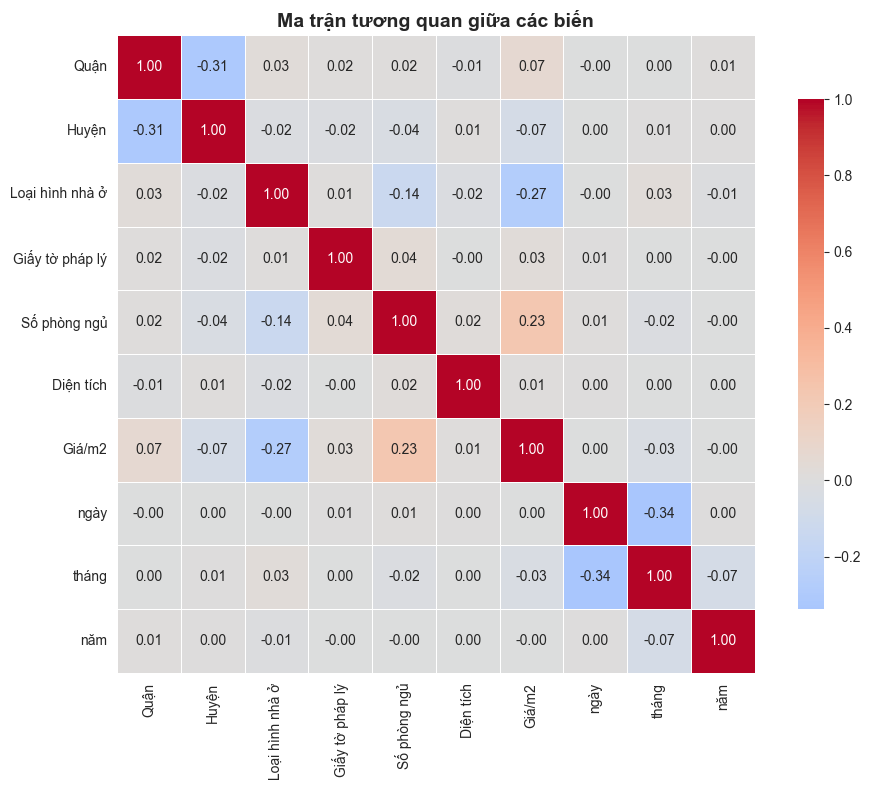


=== Tương quan của các biến với Giá/m2 ===
Giá/m2             1
Số phòng ngủ       0
Quận               0
Giấy tờ pháp lý    0
Diện tích          0
ngày               0
năm               -0
tháng             -0
Huyện             -0
Loại hình nhà ở   -0
Name: Giá/m2, dtype: float64


In [69]:
# 3. Ma trận tương quan
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Hiển thị tương quan với Giá/m2
print("\n=== Tương quan của các biến với Giá/m2 ===")
correlation_with_price = correlation_matrix['Giá/m2'].sort_values(ascending=False)
print(correlation_with_price)

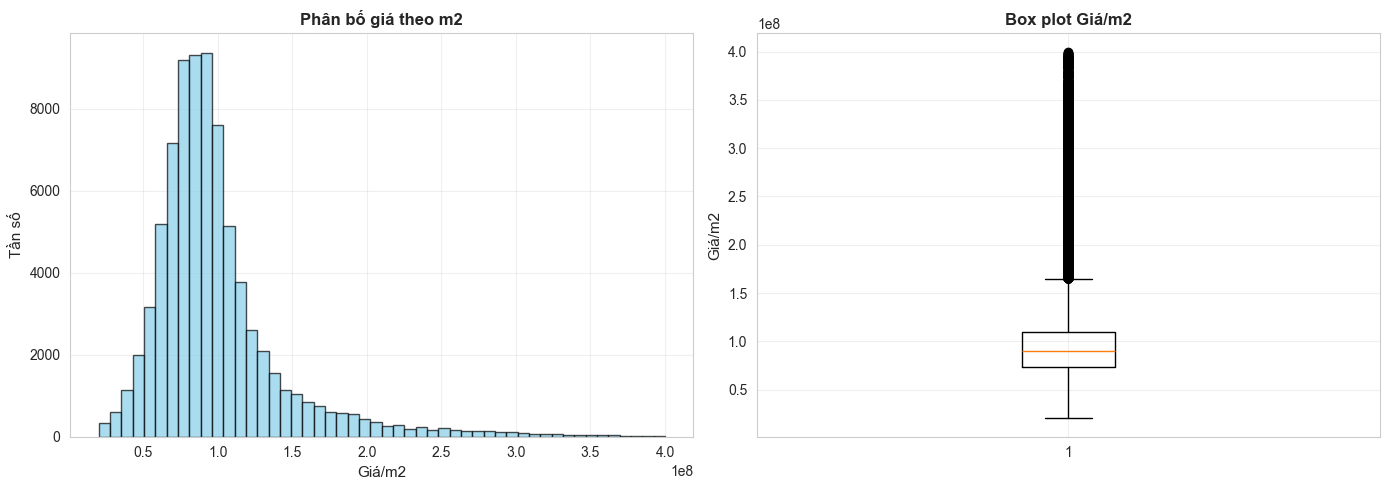


=== Thống kê mô tả Giá/m2 ===
count        79,343
mean     99,427,849
std      45,942,530
min      20,150,000
25%      73,330,000
50%      89,810,000
75%     110,000,000
max     399,990,000
Name: Giá/m2, dtype: float64


In [72]:
# 4. Phân bố của Giá/m2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_cleaned['Giá/m2'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Giá/m2', fontsize=11)
axes[0].set_ylabel('Tần số', fontsize=11)
axes[0].set_title('Phân bố giá theo m2', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_cleaned['Giá/m2'], vert=True)
axes[1].set_ylabel('Giá/m2', fontsize=11)
axes[1].set_title('Box plot Giá/m2', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Thống kê mô tả
print("\n=== Thống kê mô tả Giá/m2 ===")
print(df_cleaned['Giá/m2'].describe())

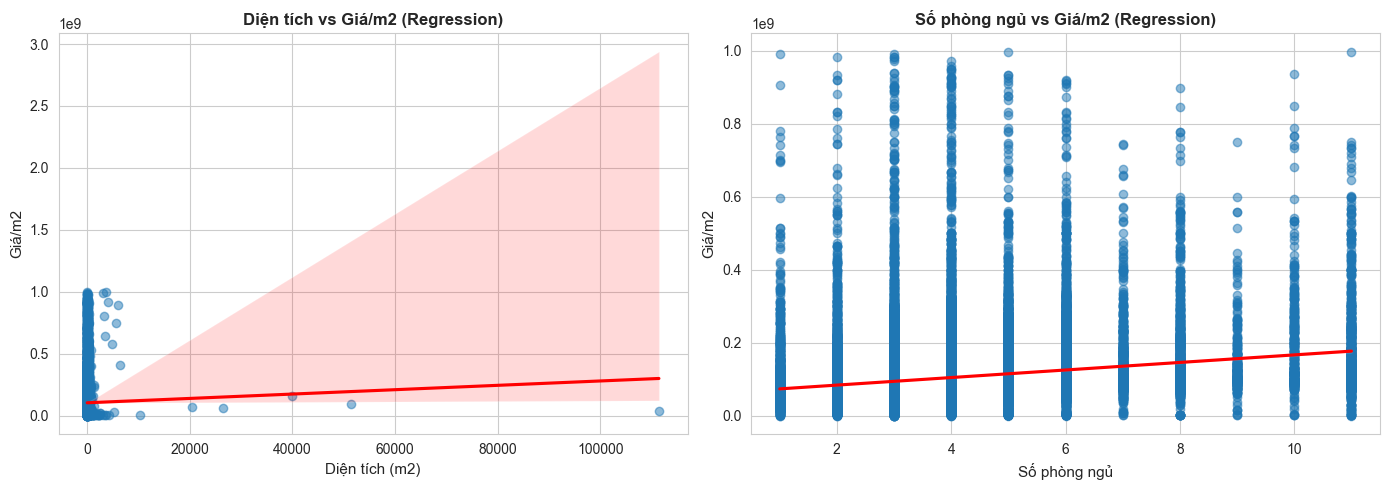

In [71]:
# 5. Regression plot cho các biến quan trọng
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diện tích vs Giá/m2
sns.regplot(x='Diện tích', y='Giá/m2', data=df, ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Diện tích vs Giá/m2 (Regression)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diện tích (m2)', fontsize=11)
axes[0].set_ylabel('Giá/m2', fontsize=11)

# Số phòng ngủ vs Giá/m2
sns.regplot(x='Số phòng ngủ', y='Giá/m2', data=df, ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Số phòng ngủ vs Giá/m2 (Regression)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số phòng ngủ', fontsize=11)
axes[1].set_ylabel('Giá/m2', fontsize=11)

plt.tight_layout()
plt.show()

III. Train

In [140]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [141]:
print(df.dtypes)

Quận               int64
Huyện              int64
Loại hình nhà ở    int64
Giấy tờ pháp lý    int64
Số phòng ngủ       Int64
Diện tích          int64
Giá/m2             int64
ngày               Int64
tháng              Int64
năm                Int64
price_per_room     int64
area_per_room      Int64
rooms_per_100m2    Int64
price_level        int64
area_category      int64
is_peak_season     int64
is_winter          int64
is_summer          int64
is_quarter_end     int64
listing_age        Int64
room_area_ratio    Int64
property_score     Int64
location_score     int64
dtype: object


In [153]:
print("⚠️  REMOVENDO DATA LEAKAGE")
print("="*60)
print("Problema: 'price_per_room' e 'price_level' são derivados de Giá/m2 (target)")
print("Solução: Usar apenas features independentes\n")

# Features sem data leakage - apenas características intrínsecas do imóvel + tempo
features_clean = [
    'Quận',                    # Localização (quarteirão)
    'Huyện',                   # Localização (distrito)
    'Loại hình nhà ở',         # Tipo de propriedade
    'Giấy tờ pháp lý',         # Documentação legal
    'Số phòng ngủ',            # Número de quartos
    'Diện tích',               # Área (m²)
    'ngày', 'tháng', 'năm',    # Data do anúncio
    'is_peak_season',          # Mês de pico
    'is_winter', 'is_summer',  # Sazonalidade
    'listing_age',             # Idade do anúncio
    'rooms_per_100m2',         # Densidade de quartos (independente)
    'room_area_ratio',         # Proporção quarto/área (independente)
    'location_score'           # Score de localização (independente)
]

print(f"✅ Usando {len(features_clean)} features limpas (sem data leakage):")
for i, feat in enumerate(features_clean, 1):
    print(f"   {i:2d}. {feat}")

print("\n❌ Removendo features com data leakage:")
print("   - price_per_room (usa Giá/m2 diretamente)")
print("   - price_level (baseado em quantis de Giá/m2)")
print("   - area_per_room (menos crítico)")
print("   - property_score (usa indiretamente)")
print("   - area_category (baseado em quantis de Diện tích)")

X = df_cleaned[features_clean]
y = np.log1p(df_cleaned['Giá/m2'])

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

⚠️  REMOVENDO DATA LEAKAGE
Problema: 'price_per_room' e 'price_level' são derivados de Giá/m2 (target)
Solução: Usar apenas features independentes

✅ Usando 16 features limpas (sem data leakage):
    1. Quận
    2. Huyện
    3. Loại hình nhà ở
    4. Giấy tờ pháp lý
    5. Số phòng ngủ
    6. Diện tích
    7. ngày
    8. tháng
    9. năm
   10. is_peak_season
   11. is_winter
   12. is_summer
   13. listing_age
   14. rooms_per_100m2
   15. room_area_ratio
   16. location_score

❌ Removendo features com data leakage:
   - price_per_room (usa Giá/m2 diretamente)
   - price_level (baseado em quantis de Giá/m2)
   - area_per_room (menos crítico)
   - property_score (usa indiretamente)
   - area_category (baseado em quantis de Diện tích)

✅ X shape: (79343, 16)
✅ y shape: (79343,)


In [154]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
model = xgb.XGBRegressor (
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=100,
    min_child_weights=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    tree_method='hist'
) 
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

c:\Program Files\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "min_child_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-rmse:0.38290
[100]	validation_0-rmse:0.27992
[200]	validation_0-rmse:0.27883
[300]	validation_0-rmse:0.27871
[400]	validation_0-rmse:0.27864
[500]	validation_0-rmse:0.27861
[600]	validation_0-rmse:0.27856
[700]	validation_0-rmse:0.27856
[800]	validation_0-rmse:0.27856
[900]	validation_0-rmse:0.27856
[1000]	validation_0-rmse:0.27855
[1100]	validation_0-rmse:0.27855
[1200]	validation_0-rmse:0.27853
[1300]	validation_0-rmse:0.27852
[1400]	validation_0-rmse:0.27852
[1500]	validation_0-rmse:0.27852
[1600]	validation_0-rmse:0.27851
[1700]	validation_0-rmse:0.27851
[1800]	validation_0-rmse:0.27850
[1900]	validation_0-rmse:0.27850
[1999]	validation_0-rmse:0.27850


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [156]:
y_pred=model.predict(X_test)
print(f"R² score: {r2_score(y_test, y_pred):.4f}")

R² score: 0.4854
